In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB



In [11]:
df = pd.read_csv("../data/processed_data.csv")

df.head()

,sex,agegrp,rowtotal_17,rowtotal_18,rowtotal_20,high_illiteracy_risk,early_edu_rate,primary_rate,secondary_rate,slc_rate,...,attending_rate,ever_attending_rate,never_attending_rate,prov_1,prov_2,prov_3,prov_4,prov_5,prov_6,prov_7
0,1,5,144,134,144,1,1.000000,0.000000,0.0,0.0,...,0.930556,0.000000,0.069444,True,False,False,False,False,False,False
1,1,6,132,129,132,1,0.147287,0.852713,0.0,0.0,...,0.977273,0.000000,0.022727,True,False,False,False,False,False,False
2,1,7,122,119,122,1,0.042017,0.957983,0.0,0.0,...,0.975410,0.000000,0.024590,True,False,False,False,False,False,False
3,1,8,113,107,113,1,0.028037,0.971963,0.0,0.0,...,0.946903,0.000000,0.053097,True,False,False,False,False,False,False
4,1,9,127,125,127,0,0.000000,1.000000,0.0,0.0,...,0.960630,0.023622,0.015748,True,False,False,False,False,False,False


In [12]:
X = df.drop(["high_illiteracy_risk", "never_attending_rate"], axis=1)
y = df["high_illiteracy_risk"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [15]:
y_pred = model.predict(X_test)

In [16]:

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Print results
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}\n")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:  0.8112
Precision: 0.8975
Recall:    0.7008
F1-Score:  0.7871

Confusion Matrix:
 [[1648  142]
 [ 531 1244]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.92      0.83      1790
           1       0.90      0.70      0.79      1775

    accuracy                           0.81      3565
   macro avg       0.83      0.81      0.81      3565
weighted avg       0.83      0.81      0.81      3565



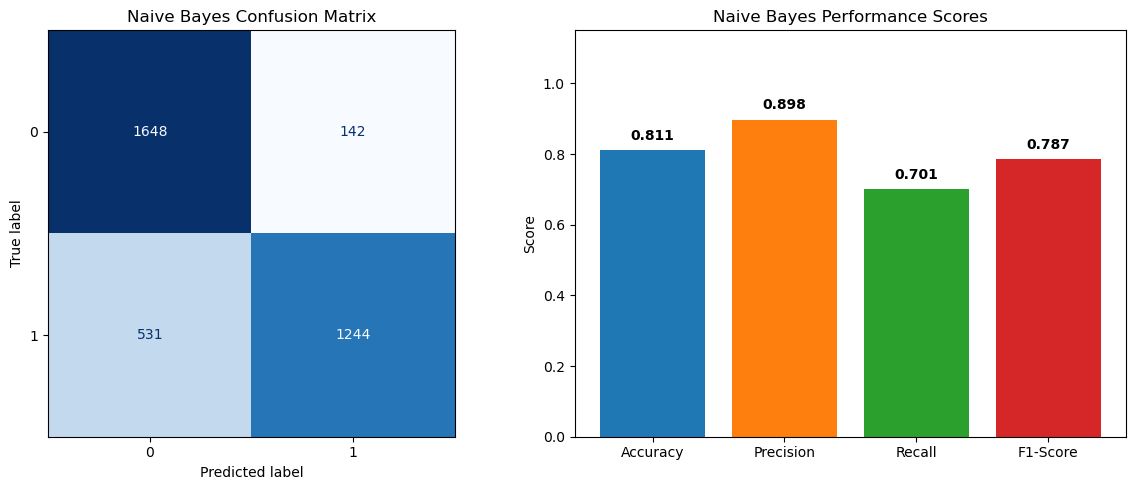

In [17]:
# Plot Confusion Matrix and Evaluation Metrics 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Naive Bayes Confusion Matrix")


metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_values = [acc, prec, rec, f1]
bars = axes[1].bar(
    metrics_names, metrics_values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)

axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Score")
axes[1].set_title("Naive Bayes Performance Scores")

# Add exact numeric values above each bar
for bar, val in zip(bars, metrics_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()